In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/yasserh/twitter-tweets-sentiment-dataset/Tweets.csv


In [2]:
##Importing the reqired Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os

import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression

from sentence_transformers import SentenceTransformer
from wordcloud import WordCloud

In [3]:

##Load Dataset
path = kagglehub.dataset_download("yasserh/twitter-tweets-sentiment-dataset")
df = pd.read_csv(os.path.join(path, "Tweets.csv"))
df.head() 

##Dataset Information
df.info()
df.describe()
df["sentiment"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27481 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27481 non-null  object
dtypes: object(4)
memory usage: 858.9+ KB


sentiment
neutral     11118
positive     8582
negative     7781
Name: count, dtype: int64

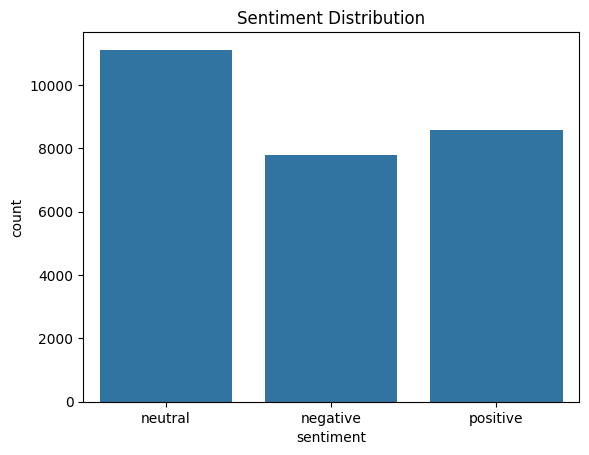

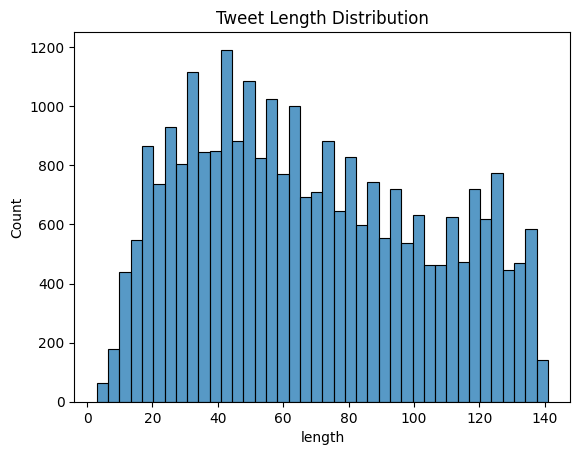

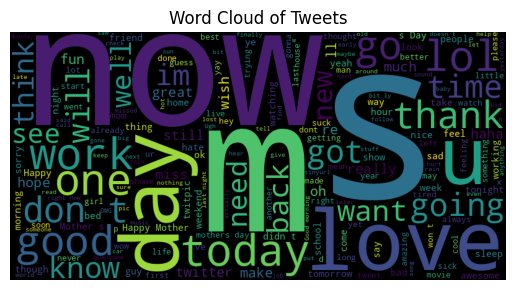

In [4]:
##Exploratory Data Analysis (EDA)
##Sentiment Distribution
sns.countplot(x="sentiment", data=df)
plt.title("Sentiment Distribution")
plt.show()
df["length"] = df["text"].astype(str).apply(len)

##Tweet Length Distribution

sns.histplot(df["length"], bins=40)
plt.title("Tweet Length Distribution")
plt.show()
text = " ".join(df["text"].astype(str))

##Word Cloud Visualization

wordcloud = WordCloud(width=800, height=400).generate(text)

plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud of Tweets")
plt.show()

In [5]:
##Text Preprocessing

df["text"] = df["text"].astype(str)

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text

df["clean_text"] = df["text"].apply(clean_text)

df[["text","clean_text"]].head()

,text,clean_text
0,"I`d have responded, if I were going",id have responded if i were going
1,Sooo SAD I will miss you here in San Diego!!!,sooo sad i will miss you here in san diego
2,my boss is bullying me...,my boss is bullying me
3,what interview! leave me alone,what interview leave me alone
4,"Sons of ****, why couldn`t they put them on t...",sons of why couldnt they put them on the rel...


In [6]:
##Generate Text Embeddings

model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = model.encode(df["clean_text"].tolist(), show_progress_bar=True)

print(embeddings.shape)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/859 [00:00<?, ?it/s]

(27481, 384)


In [7]:
##Train Test Split

X = embeddings
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
##Train Classification Model and Model Evaluation

clf = LogisticRegression(max_iter=200)

clf.fit(X_train, y_train)

predictions = clf.predict(X_test)

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

    negative       0.70      0.66      0.68      1562
     neutral       0.64      0.69      0.66      2230
    positive       0.75      0.70      0.72      1705

    accuracy                           0.69      5497
   macro avg       0.69      0.68      0.69      5497
weighted avg       0.69      0.69      0.69      5497



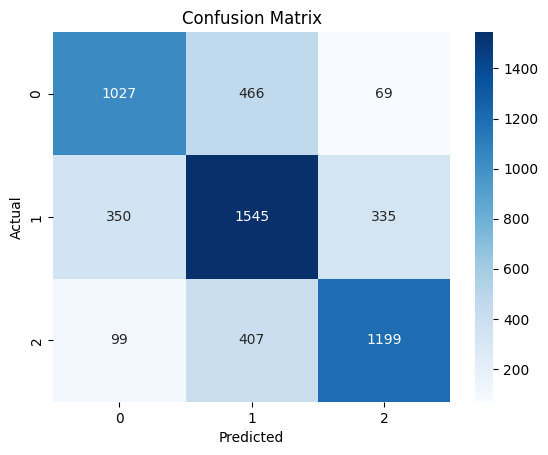

In [9]:
##Confusion Matrix

cm = confusion_matrix(y_test, predictions)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [10]:
##Custom Tweet Predictions

custom_tweets = [
    "I love this phone!",
    "This service is terrible",
    "The movie was okay",
    "Amazing performance by the team",
    "I'm very disappointed with this product"
]

custom_embeddings = model.encode(custom_tweets)

results = clf.predict(custom_embeddings)

for tweet, sentiment in zip(custom_tweets, results):
    print(tweet, "->", sentiment)

I love this phone! -> positive
This service is terrible -> negative
The movie was okay -> positive
Amazing performance by the team -> positive
I'm very disappointed with this product -> negative


# *Insights and Observations*

Example insights for your report:

The dataset contains approximately 27,000 tweets labeled as positive, negative, or neutral.

Sentiment distribution shows neutral tweets are slightly dominant.

Embedding models capture semantic meaning better than traditional bag-of-words methods.

Logistic Regression performs well with dense embedding vectors.

Tweets containing strong emotional words tend to be classified accurately.

# Conclusion

This project demonstrates how text embeddings combined with machine learning classifiers can effectively classify tweet sentiment. The embedding approach captures contextual meaning and improves classification performance compared to traditional text vectorization methods.

Future improvements could include:

Testing XGBoost classifier

Fine-tuning transformer models

Deploying the model as a web application